In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers.legacy import Adam # Using legacy because it runs faster on M1 Macs
import json
import re
import gc

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
stage = "turn"

### Reading and compacting dfs

In [3]:
compact = False

In [4]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir("dfs"):
    if file.endswith(".parquet"):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(f"dfs/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = "dfs/trash"
    for f in read:
        os.rename(f"dfs/{f}", f"{trash}/{f}")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"dfs/compacted_{timestamp}.parquet")

dfs = []  # Clear memory
raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage,origin
0,0.000333,0.001134,0.001101,0.001118,0.001203,0.000200,0.001382,0.000910,0.001050,0.000533,...,489,0,489,True,False,False,978,1469,turn,tordjes_2024-05-25_00-32-05
1,0.000829,0.000092,0.001260,0.000810,0.000211,0.001559,0.000483,0.001697,0.000439,0.001297,...,425,8,433,True,False,True,858,2134,turn,tordjes_2024-05-25_00-32-05
2,0.001482,0.001143,0.000000,0.000226,0.001568,0.001219,0.000634,0.000806,0.001333,0.000952,...,587,383,589,True,True,True,1176,2821,turn,tordjes_2024-05-25_00-32-05
3,0.000261,0.000823,0.000901,0.000124,0.000328,0.000688,0.001378,0.001491,0.001384,0.000740,...,374,24,398,True,False,True,772,1750,turn,tordjes_2024-05-25_00-32-05
4,0.000299,0.000782,0.001228,0.000976,0.000524,0.001723,0.001327,0.000854,0.000186,0.001006,...,466,12,478,True,False,True,944,1499,turn,tordjes_2024-05-25_00-32-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,240,20,260,True,False,True,500,1192,turn,tordjes_2024-05-31_14-26-19
82559,0.000201,0.000210,0.001391,0.000468,0.000000,0.000959,0.001324,0.000097,0.000883,0.001369,...,109,160,269,True,False,True,378,1405,turn,tordjes_2024-05-31_14-26-19
82560,0.000459,0.001509,0.001716,0.000608,0.001531,0.000000,0.001368,0.000000,0.000026,0.001054,...,167,0,167,True,False,True,334,1047,turn,tordjes_2024-05-31_14-26-19
82561,0.000000,0.000381,0.000000,0.000286,0.000160,0.000337,0.000000,0.000102,0.000120,0.001647,...,297,125,416,True,True,True,713,2067,turn,tordjes_2024-05-31_14-26-19


In [5]:
# Show all types of columns:
list(sorted(set(re.sub("\\d+", "X", col) for col in raw_df.columns)))

['game_size',
 'opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'origin',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'stage',
 'value_of_hand_X']

In [6]:
# Filter on stage
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage", "origin"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000333,0.001134,0.001101,0.001118,0.001203,0.000200,0.001382,0.000910,0.001050,0.000533,...,0.0,0,489,0,489,True,False,False,978,1469
1,0.000829,0.000092,0.001260,0.000810,0.000211,0.001559,0.000483,0.001697,0.000439,0.001297,...,0.0,0,425,8,433,True,False,True,858,2134
2,0.001482,0.001143,0.000000,0.000226,0.001568,0.001219,0.000634,0.000806,0.001333,0.000952,...,0.0,381,587,383,589,True,True,True,1176,2821
3,0.000261,0.000823,0.000901,0.000124,0.000328,0.000688,0.001378,0.001491,0.001384,0.000740,...,0.0,0,374,24,398,True,False,True,772,1750
4,0.000299,0.000782,0.001228,0.000976,0.000524,0.001723,0.001327,0.000854,0.000186,0.001006,...,0.0,0,466,12,478,True,False,True,944,1499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,240,20,260,True,False,True,500,1192
82559,0.000201,0.000210,0.001391,0.000468,0.000000,0.000959,0.001324,0.000097,0.000883,0.001369,...,0.0,0,109,160,269,True,False,True,378,1405
82560,0.000459,0.001509,0.001716,0.000608,0.001531,0.000000,0.001368,0.000000,0.000026,0.001054,...,0.0,0,167,0,167,True,False,True,334,1047
82561,0.000000,0.000381,0.000000,0.000286,0.000160,0.000337,0.000000,0.000102,0.000120,0.001647,...,0.0,6,297,125,416,True,True,True,713,2067


### Preprocessing

In [7]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.000000,0.332880,0.000000,0.332880,0.665759
1,0.000000,0.199157,0.003749,0.202905,0.402062
2,0.135058,0.208082,0.135767,0.208791,0.416873
3,0.000000,0.213714,0.013714,0.227429,0.441143
4,0.000000,0.310874,0.008005,0.318879,0.629753
...,...,...,...,...,...
82558,0.000000,0.201342,0.016779,0.218121,0.419463
82559,0.000000,0.077580,0.113879,0.191459,0.269039
82560,0.000000,0.159503,0.000000,0.159503,0.319007
82561,0.002903,0.143687,0.060474,0.201258,0.344944


In [8]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713415 0.0005807428967170402
Mean and sd of range features after scaling:
1.4300552019541557e-15 1.0000000000000033


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,-0.725244,0.654761,0.597513,0.627295,0.772041,-0.954319,1.080489,0.268631,0.508578,-0.380142,...,0.127076,-1.209942,1.023593,0.659272,0.693160,1.466738,-0.684938,0.610162,1.006605,-0.365211
1,0.128564,-1.140150,0.870863,0.095964,-0.935509,1.385245,-0.467142,1.624376,-0.541912,0.935010,...,1.056578,-1.298592,0.074205,1.914559,-1.298592,1.670334,0.322586,-1.298592,-1.298592,0.231795
2,1.253146,0.669280,-1.298592,-0.909190,1.401576,0.801224,-0.207247,0.088613,0.997519,0.340697,...,-0.193651,1.687285,-1.298592,1.185706,1.027399,-1.298592,-0.500368,-1.298592,0.991575,-1.298592
3,-0.848887,0.117836,0.252524,-1.085018,-0.733032,-0.114656,1.073507,1.269188,1.084978,-0.024795,...,-1.298592,-1.298592,-1.298592,-1.298592,-0.650571,-0.087216,0.265488,-0.852830,0.967519,0.136516
4,-0.783385,0.048171,0.815259,0.382152,-0.396308,1.667831,0.987144,0.172156,-0.979121,0.434081,...,-0.162815,1.336568,1.064484,-0.386448,1.661346,1.211795,0.657562,-1.236080,0.995408,-0.239326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82558,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,...,-1.148923,0.452553,-1.076509,1.578897,-0.378635,-0.186827,1.527299,-0.295259,-0.516029,1.695688
82559,-0.952429,-0.936885,1.095889,-0.492520,-1.298592,0.352369,0.980696,-1.131631,0.221894,1.059289,...,0.931467,-0.056687,-0.650017,-0.364874,1.062409,-0.234178,1.092926,1.708090,-0.818489,-1.182446
82560,-0.507552,1.300135,1.656248,-0.251598,1.337407,-1.298592,1.057128,-1.298592,-1.254644,0.516455,...,-0.124194,-0.776519,1.474714,-0.054363,-1.294042,0.870460,0.424512,1.375782,-0.830522,0.758014
82561,-1.298592,-0.642844,-1.298592,-0.806692,-1.022606,-0.718401,-1.298592,-1.123163,-1.092679,1.537205,...,1.057599,-0.912245,0.311690,-0.187969,0.871501,0.597389,0.348217,-0.336217,-1.118484,-0.203496


In [9]:
# Make boolean features 0 or 1
bool_columns = [
    "player_turn",
    "player_has_bet",
    "opponent_has_bet",
]


def encode_bools(df):
    df[bool_columns] = df[bool_columns].astype(int)


encode_bools(df)
df[bool_columns]

,player_turn,player_has_bet,opponent_has_bet
0,1,0,0
1,1,0,1
2,1,1,1
3,1,0,1
4,1,0,1
...,...,...,...
82558,1,0,1
82559,1,0,1
82560,1,0,1
82561,1,1,1


In [10]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-0.725244,0.654761,0.597513,0.627295,0.772041,-0.954319,1.080489,0.268631,0.508578,-0.380142,...,0.0,0.0,0.000000,0.332880,0.000000,0.332880,1,0,0,0.665759
1,0.128564,-1.140150,0.870863,0.095964,-0.935509,1.385245,-0.467142,1.624376,-0.541912,0.935010,...,0.0,0.0,0.000000,0.199157,0.003749,0.202905,1,0,1,0.402062
2,1.253146,0.669280,-1.298592,-0.909190,1.401576,0.801224,-0.207247,0.088613,0.997519,0.340697,...,1.0,0.0,0.135058,0.208082,0.135767,0.208791,1,1,1,0.416873
3,-0.848887,0.117836,0.252524,-1.085018,-0.733032,-0.114656,1.073507,1.269188,1.084978,-0.024795,...,0.0,0.0,0.000000,0.213714,0.013714,0.227429,1,0,1,0.441143
4,-0.783385,0.048171,0.815259,0.382152,-0.396308,1.667831,0.987144,0.172156,-0.979121,0.434081,...,0.0,0.0,0.000000,0.310874,0.008005,0.318879,1,0,1,0.629753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82558,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,...,0.0,0.0,0.000000,0.201342,0.016779,0.218121,1,0,1,0.419463
82559,-0.952429,-0.936885,1.095889,-0.492520,-1.298592,0.352369,0.980696,-1.131631,0.221894,1.059289,...,0.0,0.0,0.000000,0.077580,0.113879,0.191459,1,0,1,0.269039
82560,-0.507552,1.300135,1.656248,-0.251598,1.337407,-1.298592,1.057128,-1.298592,-1.254644,0.516455,...,0.0,0.0,0.000000,0.159503,0.000000,0.159503,1,0,1,0.319007
82561,-1.298592,-0.642844,-1.298592,-0.806692,-1.022606,-0.718401,-1.298592,-1.123163,-1.092679,1.537205,...,0.0,0.0,0.002903,0.143687,0.060474,0.201258,1,1,1,0.344944


In [11]:
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-0.725244,0.654761,0.597513,0.627295,0.772041,-0.954319,1.080489,0.268631,0.508578,-0.380142,...,0.0,0.0,0.000000,0.332880,0.000000,0.332880,1,0,0,0.665759
1,0.128564,-1.140150,0.870863,0.095964,-0.935509,1.385245,-0.467142,1.624376,-0.541912,0.935010,...,0.0,0.0,0.000000,0.199157,0.003749,0.202905,1,0,1,0.402062
2,1.253146,0.669280,-1.298592,-0.909190,1.401576,0.801224,-0.207247,0.088613,0.997519,0.340697,...,1.0,0.0,0.135058,0.208082,0.135767,0.208791,1,1,1,0.416873
3,-0.848887,0.117836,0.252524,-1.085018,-0.733032,-0.114656,1.073507,1.269188,1.084978,-0.024795,...,0.0,0.0,0.000000,0.213714,0.013714,0.227429,1,0,1,0.441143
4,-0.783385,0.048171,0.815259,0.382152,-0.396308,1.667831,0.987144,0.172156,-0.979121,0.434081,...,0.0,0.0,0.000000,0.310874,0.008005,0.318879,1,0,1,0.629753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82558,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,-1.298592,...,0.0,0.0,0.000000,0.201342,0.016779,0.218121,1,0,1,0.419463
82559,-0.952429,-0.936885,1.095889,-0.492520,-1.298592,0.352369,0.980696,-1.131631,0.221894,1.059289,...,0.0,0.0,0.000000,0.077580,0.113879,0.191459,1,0,1,0.269039
82560,-0.507552,1.300135,1.656248,-0.251598,1.337407,-1.298592,1.057128,-1.298592,-1.254644,0.516455,...,0.0,0.0,0.000000,0.159503,0.000000,0.159503,1,0,1,0.319007
82561,-1.298592,-0.642844,-1.298592,-0.806692,-1.022606,-0.718401,-1.298592,-1.123163,-1.092679,1.537205,...,0.0,0.0,0.002903,0.143687,0.060474,0.201258,1,1,1,0.344944


In [12]:
# Show all types of columns after preprocessing:
list(sorted(set(re.sub("\\d+", "X", col) for col in df.columns)))

['opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'value_of_hand_X']

### Data validation

In [13]:
value_columns = [col for col in df.columns if col.startswith("value_")]
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: 0.02149645100697633
SD of target variable: 0.18303594553577113
Min of target variable: -62.03136548104375
Max of target variable: 11.694039419669693


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,0.195906,0.026030,0.014183,0.072099,0.013638,-0.000136,-0.199383,-0.002102,-0.000096,-0.000192,...,-0.143230,-0.000161,-0.000285,-0.000070,0.263218,-0.000144,-0.000167,-0.000190,-2.334223e-04,-0.000088
1,0.003923,0.015578,0.003003,0.000880,0.011839,-0.006609,0.004142,-0.001147,-0.000255,-0.033701,...,-0.110036,0.000010,-0.048660,-0.053057,0.000072,-0.000387,-0.066713,0.000004,-5.166461e-07,-0.063003
2,0.221845,0.232192,-0.000232,0.068793,0.131804,0.082727,-0.090613,0.052119,-0.002021,-0.002150,...,0.065919,0.017688,0.001370,-0.079088,0.032479,0.017086,-0.067789,0.028492,-5.739061e-02,-0.000129
3,0.047325,-0.013612,0.040519,0.020407,0.053797,0.039797,0.032573,-0.025895,0.008760,0.005450,...,-0.000848,-0.001606,-0.004307,-0.001729,-0.004792,-0.014754,-0.009637,-0.013973,-5.812349e-03,-0.023427
4,-0.043259,2.903113,-0.362843,1.672534,0.242722,0.706260,0.285427,0.018570,0.000479,-0.000123,...,0.000230,0.000045,-0.000467,-0.250072,0.001942,-0.000607,-0.216191,-0.000133,-1.850832e-03,-0.001339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82558,-0.000449,-0.002413,-0.001173,-0.001764,-0.000512,-0.007766,-0.001281,-0.001511,0.004818,-0.000177,...,0.012946,-0.004294,-0.009789,-0.015113,-0.001754,-0.004734,-0.009898,-0.007965,-1.510813e-02,-0.012907
82559,-0.001142,-0.002911,-0.011888,-0.019168,-0.000056,-0.053213,-0.088367,-0.052035,-0.068860,-0.042137,...,1.176840,-0.057280,0.386207,-0.158135,-0.085312,0.686807,0.234747,-0.104296,-9.335535e-02,0.087040
82560,0.131175,0.148706,0.033734,-0.021570,0.029395,-0.000011,-0.057029,-0.001756,-0.055199,-0.178470,...,-0.005765,-0.000335,-0.000010,-0.000015,-0.000370,-0.010097,-0.000019,-0.042512,-6.063773e-04,-0.000635
82561,0.077582,-0.048002,-0.000328,-0.014273,-0.067595,-0.076437,-0.000328,-0.050076,-0.060361,-0.072022,...,0.070512,0.017824,-0.022024,-0.023097,0.017237,-0.013278,-0.025022,-0.021548,-2.598136e-02,-0.041994


In [14]:
# Remove any rows with target values outside [-1, 1]
df = df[(df[value_columns] >= -1).all(axis=1) & (df[value_columns] <= 1).all(axis=1)]
print("After removing outliers:")
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())

After removing outliers:
Mean of target variable: 0.011931755889351085
SD of target variable: 0.08184258365567877
Min of target variable: -0.9999121901419775
Max of target variable: 0.9997629011825975


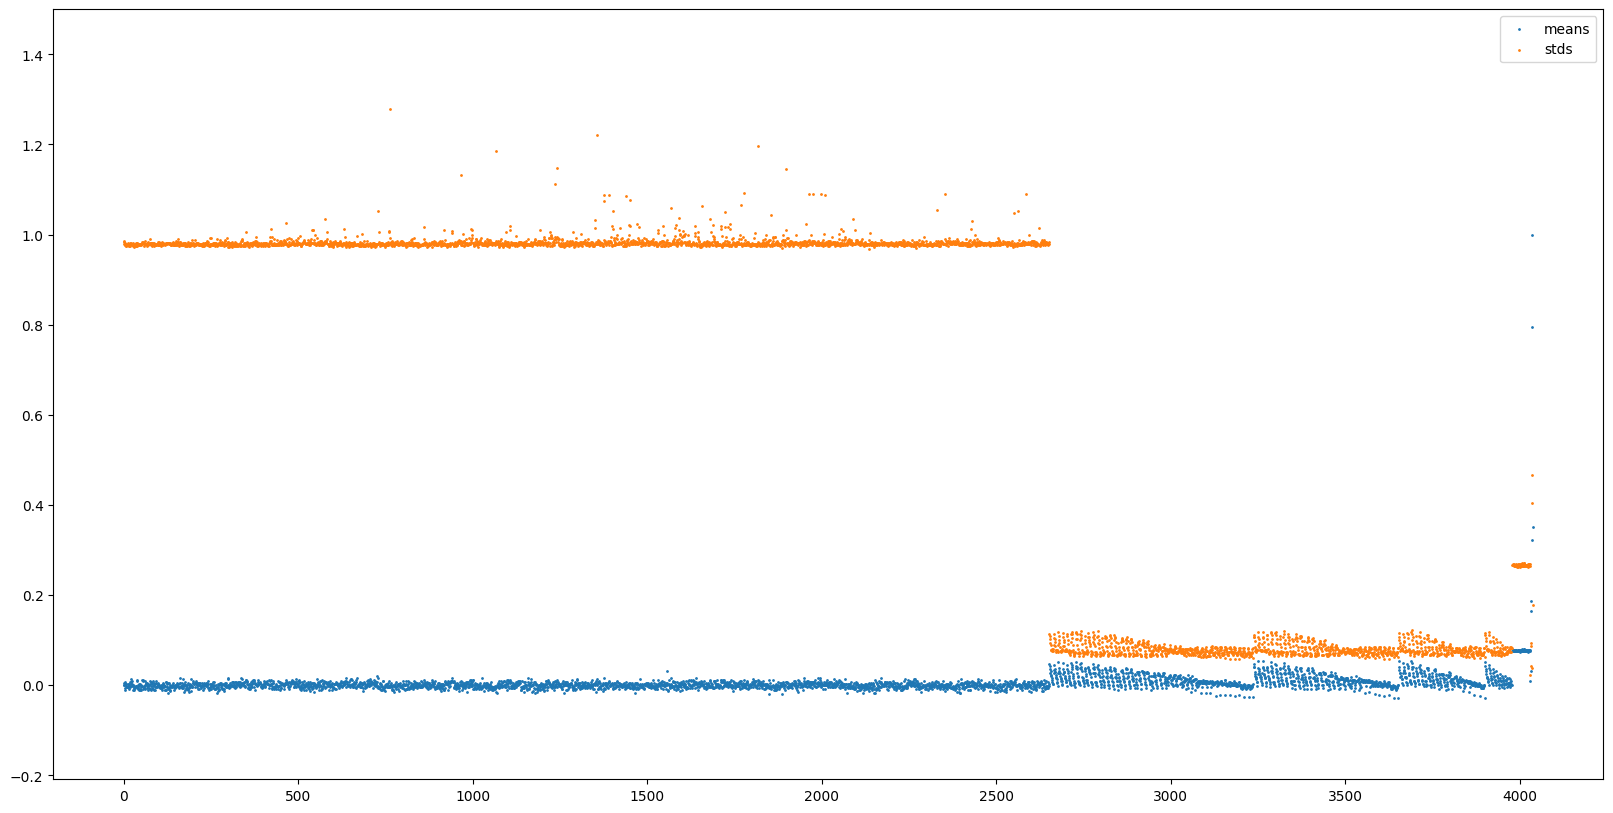

In [15]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means", s=1)
plt.scatter(range(df.std().size), df.std(), label="stds", s=1)
plt.legend()
plt.ylim(top=1.5)
plt.show()

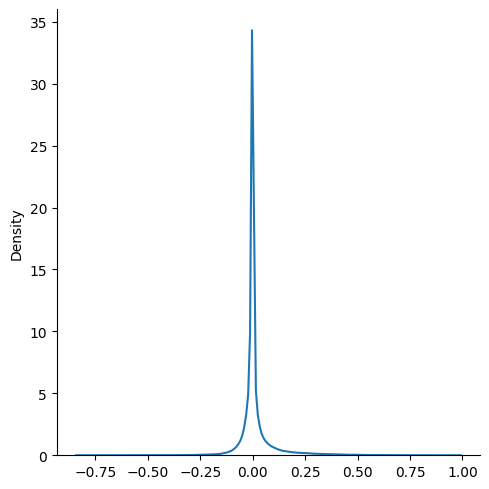

In [16]:
# Plot distribution of target values in a bell curve
from seaborn import displot

# Sample 1000 rows to speed up plotting
displot(df[value_columns].sample(1000).to_numpy().flatten(), kind="kde")
plt.show()

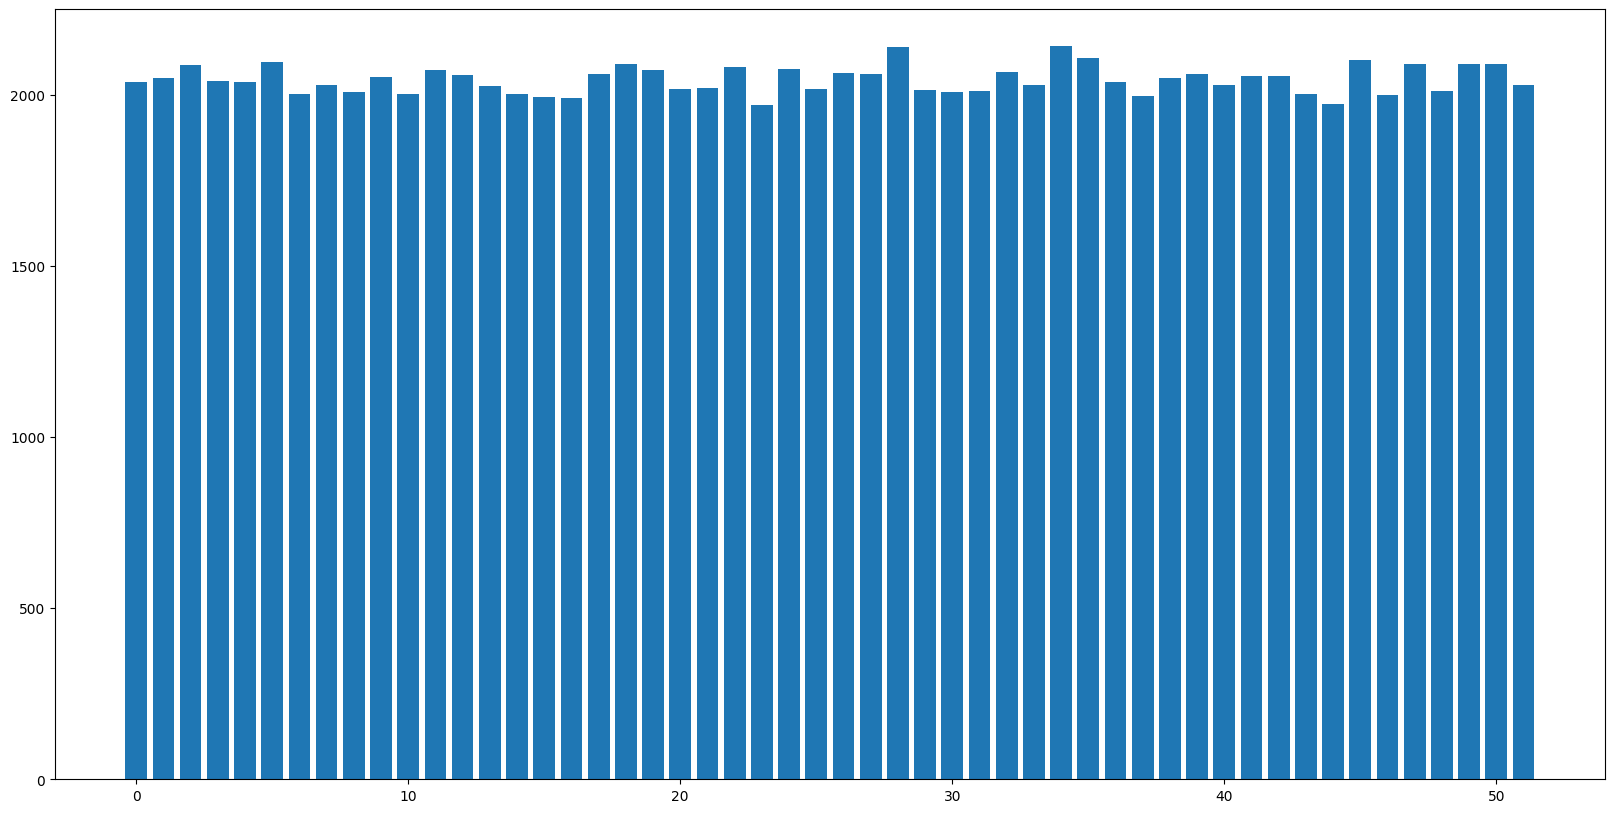

In [17]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_") and "*" not in col]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

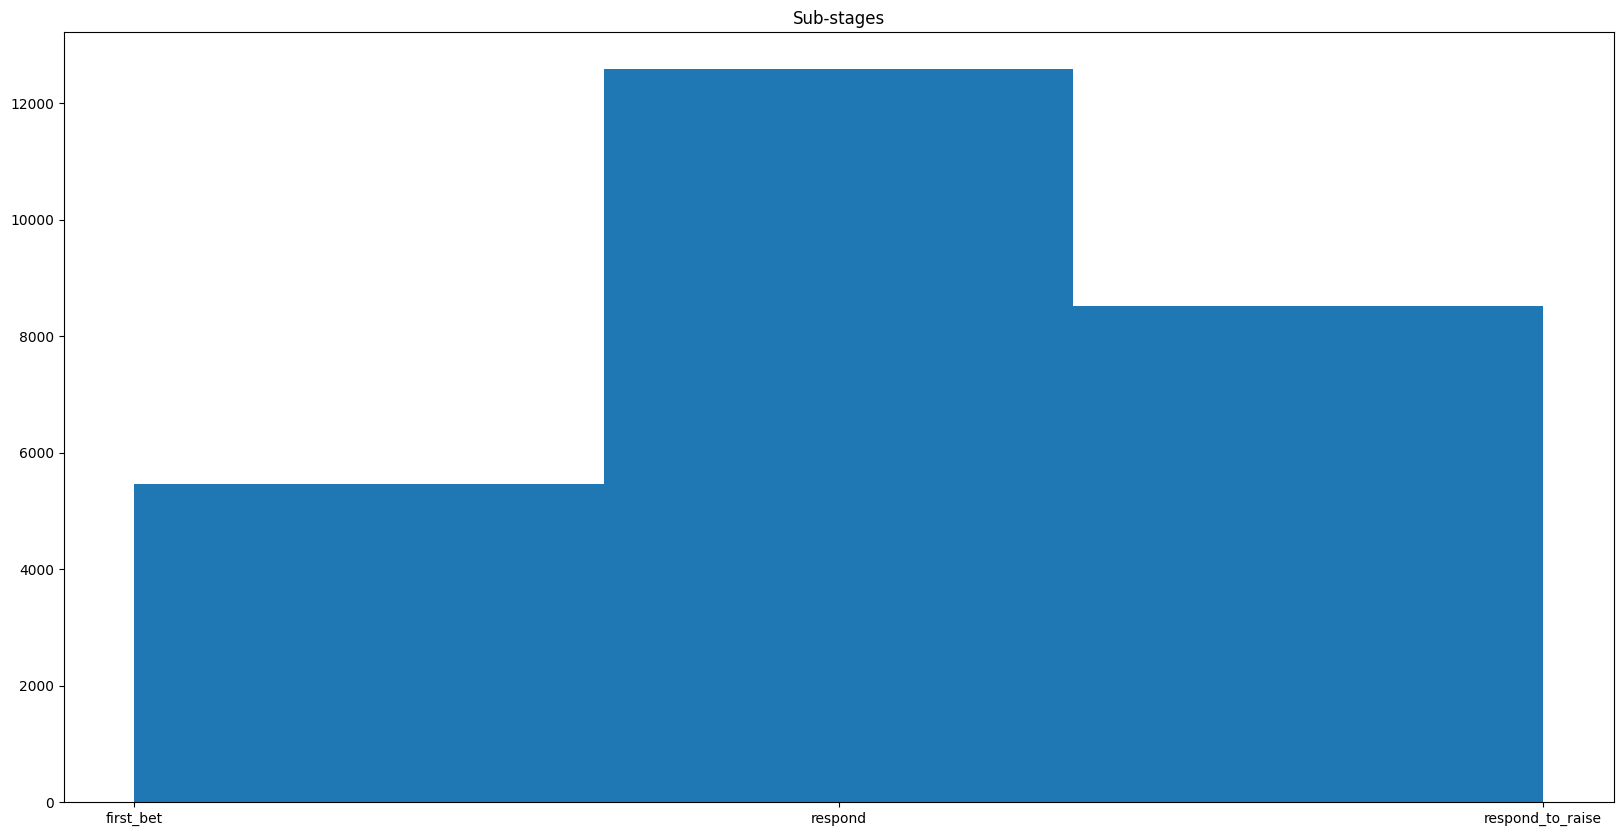

In [18]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [19]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(26577, 2712) (26577, 1326)


### Structure for Neural Network

In [20]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [21]:
def generate_model(l1_rate=1e-9, l2_rate=1e-8):
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define a small standard deviation for the initial weights
    init = RandomNormal(mean=0.0, stddev=0.002, seed=42)

    # Only use one hidden layer for now because we have so little data
    hidden_layer_1 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(input_layer)

    hidden_layer_2 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_2",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_1)

    hidden_layer_3 = Dense(
        1326 * 5,
        activation="relu",
        name="hidden_layer_3",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_2)

    # Add a dropout layer to prevent overfitting
    # dropout_layer = Dropout(0.5)(hidden_layer_3)

    # Define output layer
    value_layer_P1 = Dense(
        Y.shape[1],
        activation="linear",
        name="value_layer_P1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(hidden_layer_3)

    # Naturally, the target variable is centered around 0 with a SD of ~0.1, thus
    # to get an SD of 1, it is scaled by 10. To make this scaling implicit in the model,
    # rather than having to do it in the preprocessing, we add a scaling layer here.
    scaling_layer = Lambda(lambda x: x * 10)(value_layer_P1)

    # Create an Adam optimizer with a small learning rate
    small_lr_optimizer = Adam(learning_rate=0.000001)

    # Create model
    model = Model(inputs=input_layer, outputs=scaling_layer)
    model.compile(optimizer=small_lr_optimizer, loss="mean_squared_error")

    return model

### Split data

In [22]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Cross validation

In [23]:
# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []
validation_predictions = []
validation_actuals = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

folds = list(kf.split(X_train))
# folds = folds[:1] # Limit the number of folds to look at

# Loop over each fold
for i, (train_index, val_index) in enumerate(folds):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)
    validation_predictions.append(model.predict(X_val_fold))
    validation_actuals.append(Y_val_fold)

@@@ FOLD 1 @@@
Size of training set: 17008


2024-05-31 18:24:03.753646: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-05-31 18:24:03.753925: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-05-31 18:24:03.753935: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-05-31 18:24:03.754010: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-05-31 18:24:03.754054: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/1000


2024-05-31 18:24:04.957484: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


532/532 [==============================] - ETA: 0s - loss: 0.0070

...

2024-06-01 13:39:06.043957: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


532/532 [==============================] - ETA: 0s - loss: 0.0071

2024-06-01 13:41:49.235498: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


532/532 [==============================] - 172s 321ms/step - loss: 0.0071 - val_loss: 0.0064
Epoch 2/1000
532/532 [==============================] - 168s 315ms/step - loss: 0.0068 - val_loss: 0.0061
Epoch 3/1000
532/532 [==============================] - 170s 319ms/step - loss: 0.0065 - val_loss: 0.0060
Epoch 4/1000
532/532 [==============================] - 179s 336ms/step - loss: 0.0063 - val_loss: 0.0059
Epoch 5/1000
532/532 [==============================] - 171s 321ms/step - loss: 0.0063 - val_loss: 0.0059
Epoch 6/1000
425/532 [======================>.......] - ETA: 5:58 - loss: 0.0062

KeyboardInterrupt: 

In [27]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history["val_loss"]
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
baseline_mse = np.mean((Y_test - np.mean(Y_train, axis=0)) ** 2)
print(f"Baseline MSE: {baseline_mse:.4f}")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Cross-Validation MSE: 0.0065 (+/- 0.0001)
Baseline MSE: 0.0063
Cross-Validation RMSE: 0.0803 (+/- 0.0108)
Baseline RMSE: 0.0797


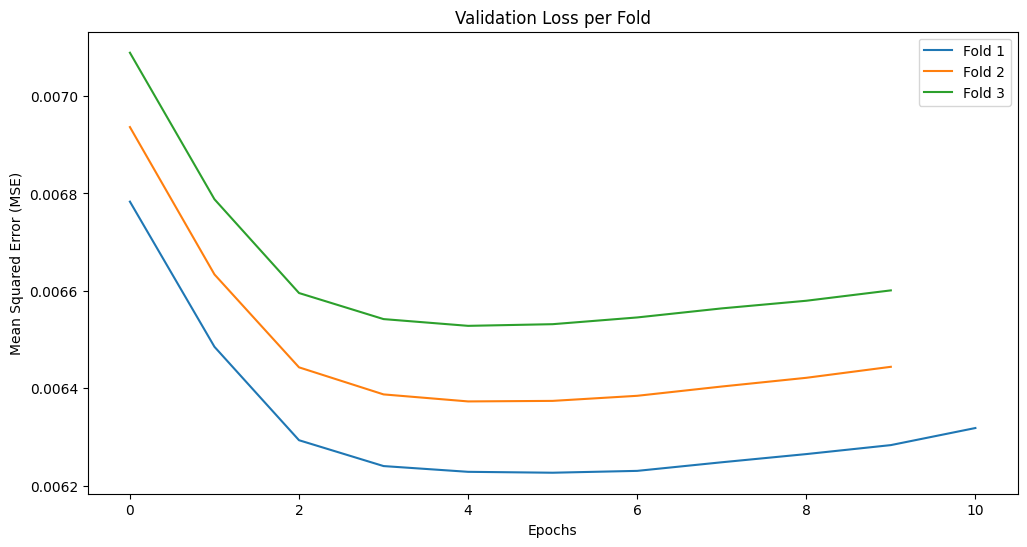

In [25]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

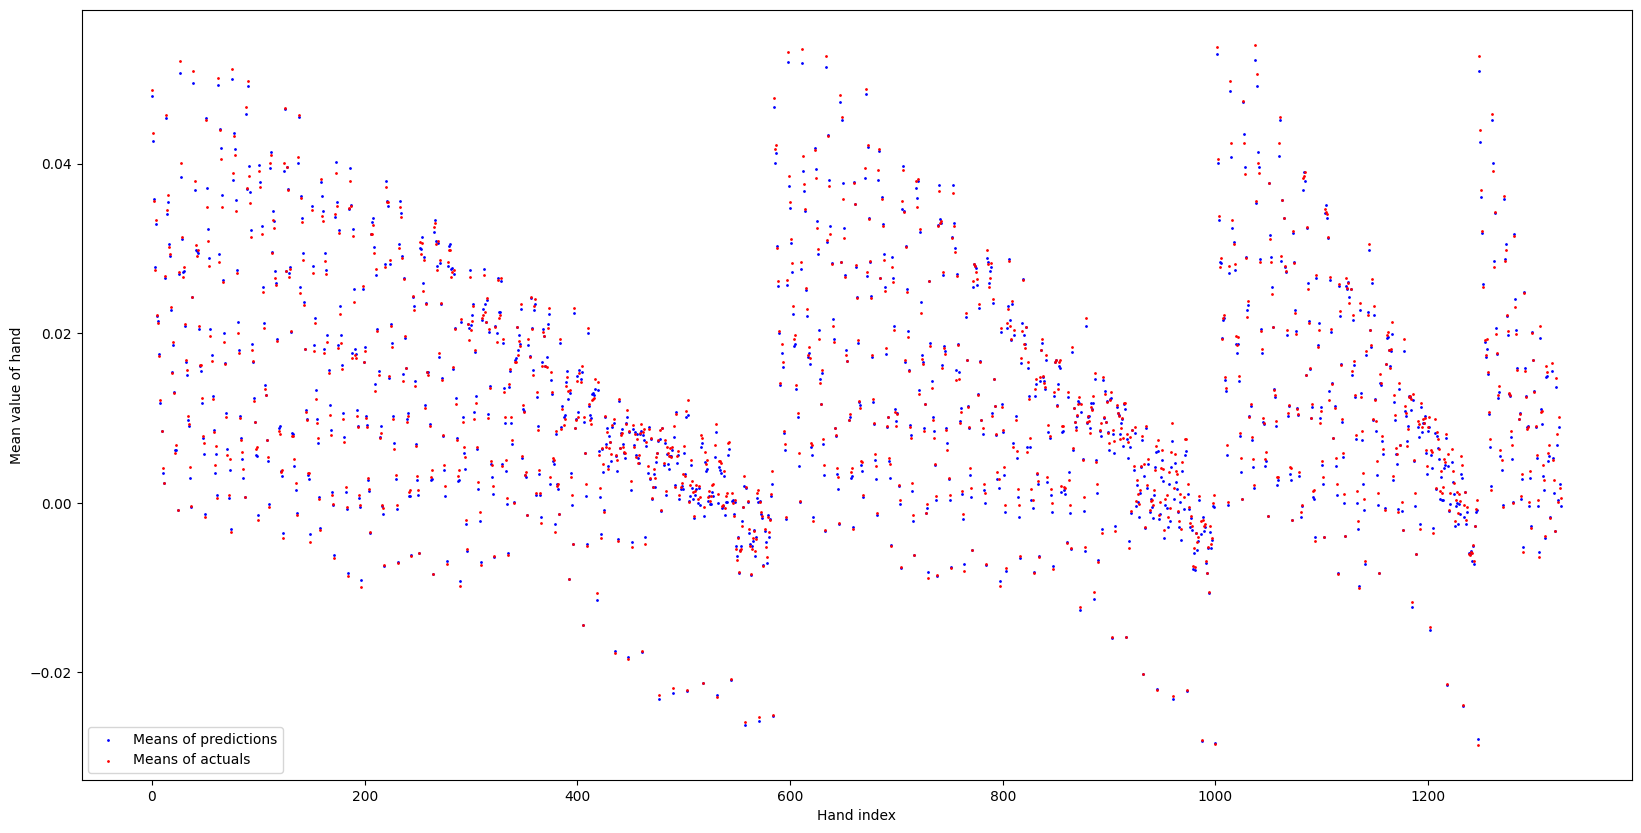

In [34]:
# Plot the distribution of outputs from the model
Y_val_pred = np.concatenate(validation_predictions)
Y_val = np.concatenate(validation_actuals)
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.mean(axis=0).size),
    Y_val_pred.mean(axis=0),
    label="Means of predictions",
    s=1,
    c="blue",
)
plt.scatter(
    range(Y_val.mean(axis=0).size),
    Y_val.mean(axis=0),
    label="Means of actuals",
    s=1,
    c="red",
)        
plt.xlabel("Hand index")
plt.ylabel("Mean value of hand")
plt.legend()
plt.show()

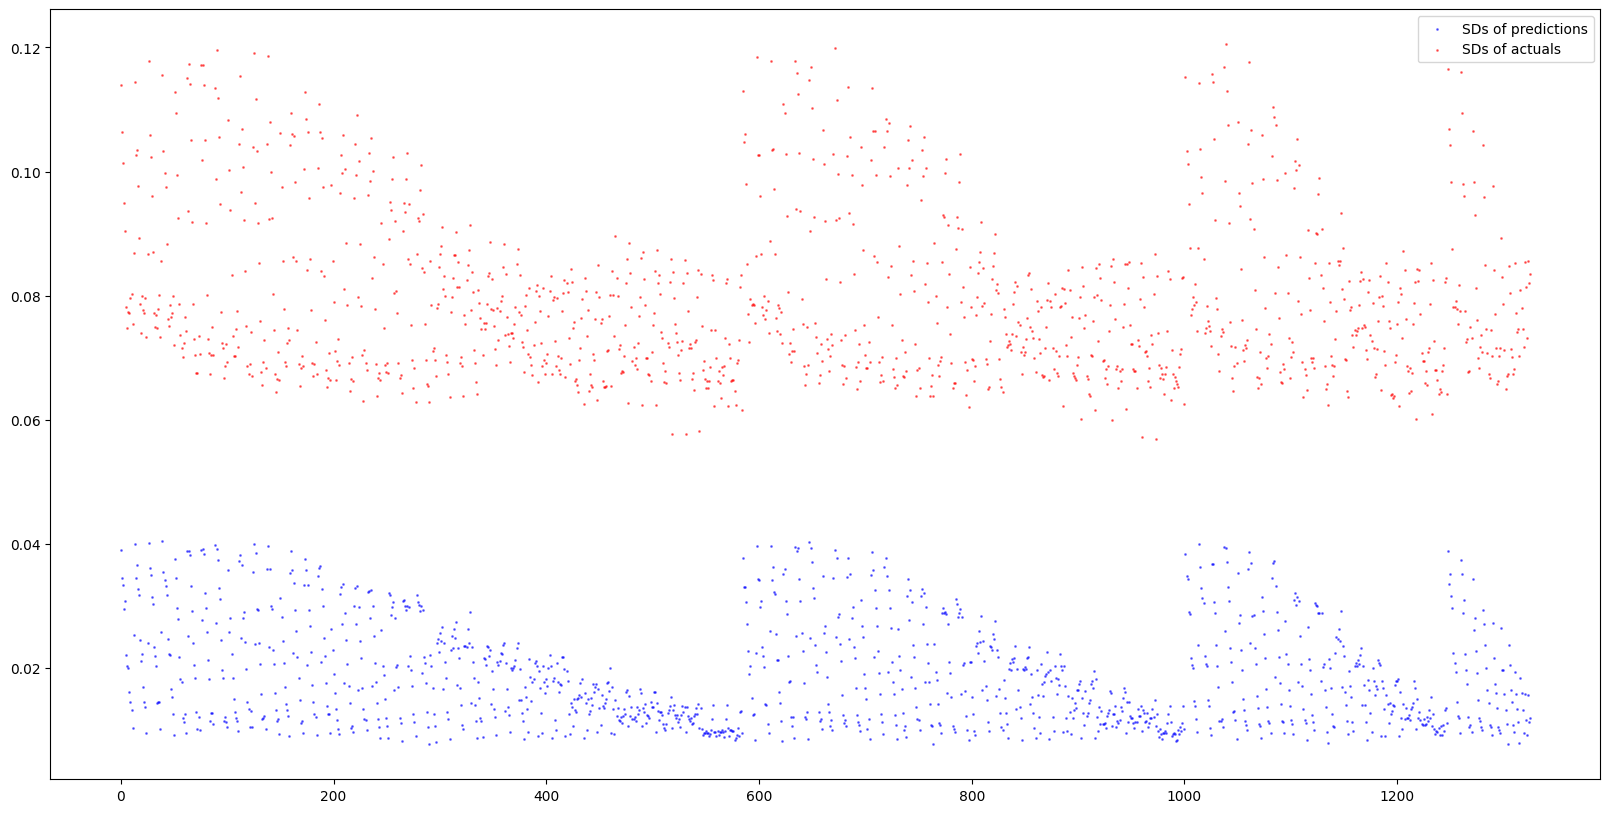

In [27]:
# Plot the distribution of outputs from the model
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.std(axis=0).size),
    Y_val_pred.std(axis=0),
    label="SDs of predictions",
    s=1,
    c="blue",
    alpha=0.5,
)
plt.scatter(
    range(Y_val.std(axis=0).size),
    Y_val.std(axis=0),
    label="SDs of actuals",
    s=1,
    c="red",
    alpha=0.5,
)
plt.legend()
plt.show()

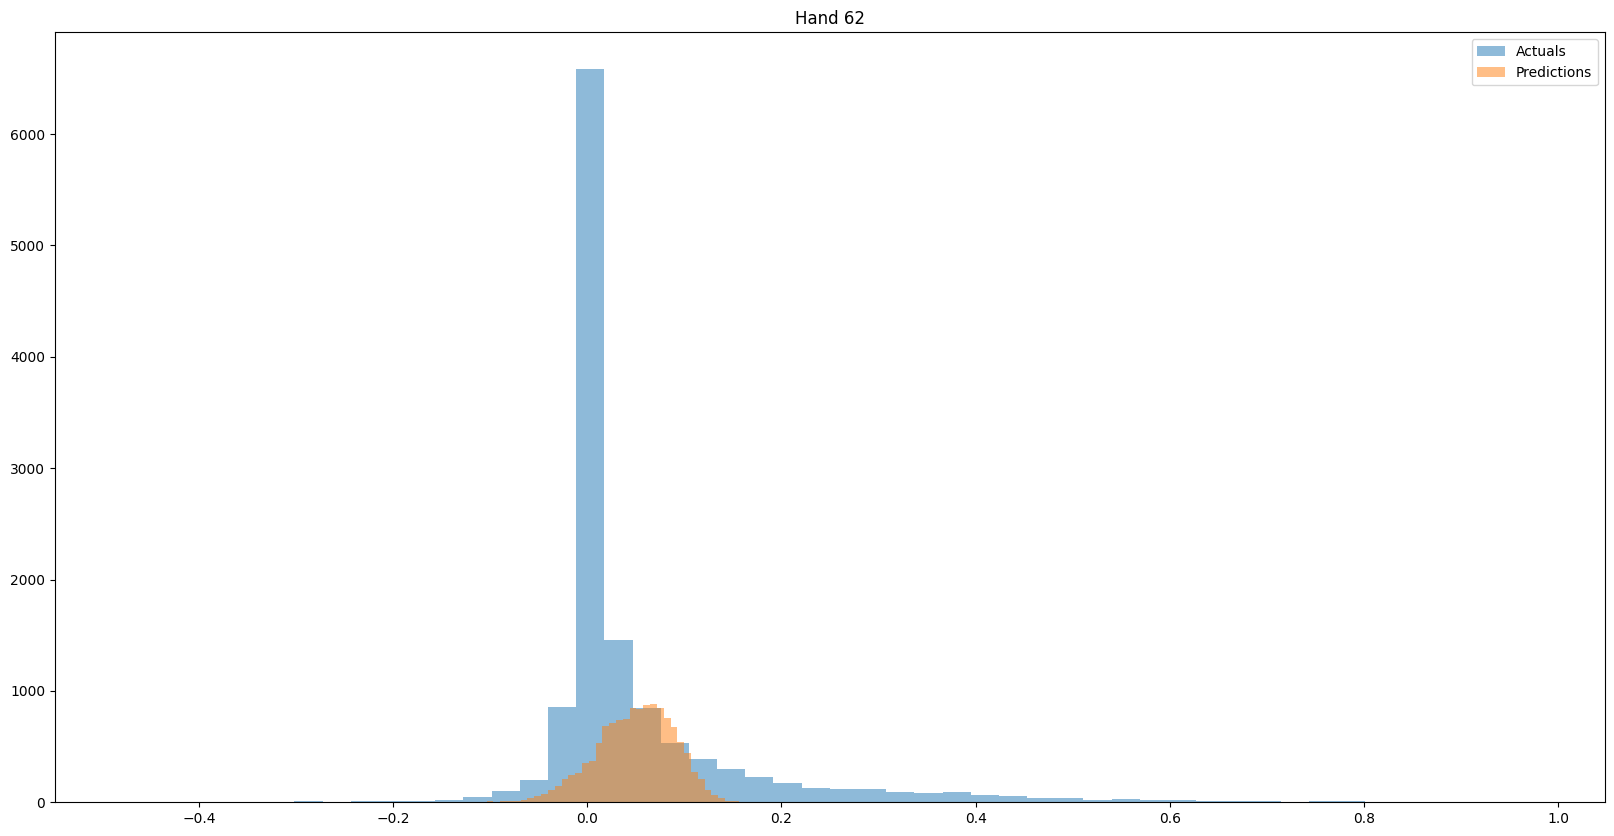

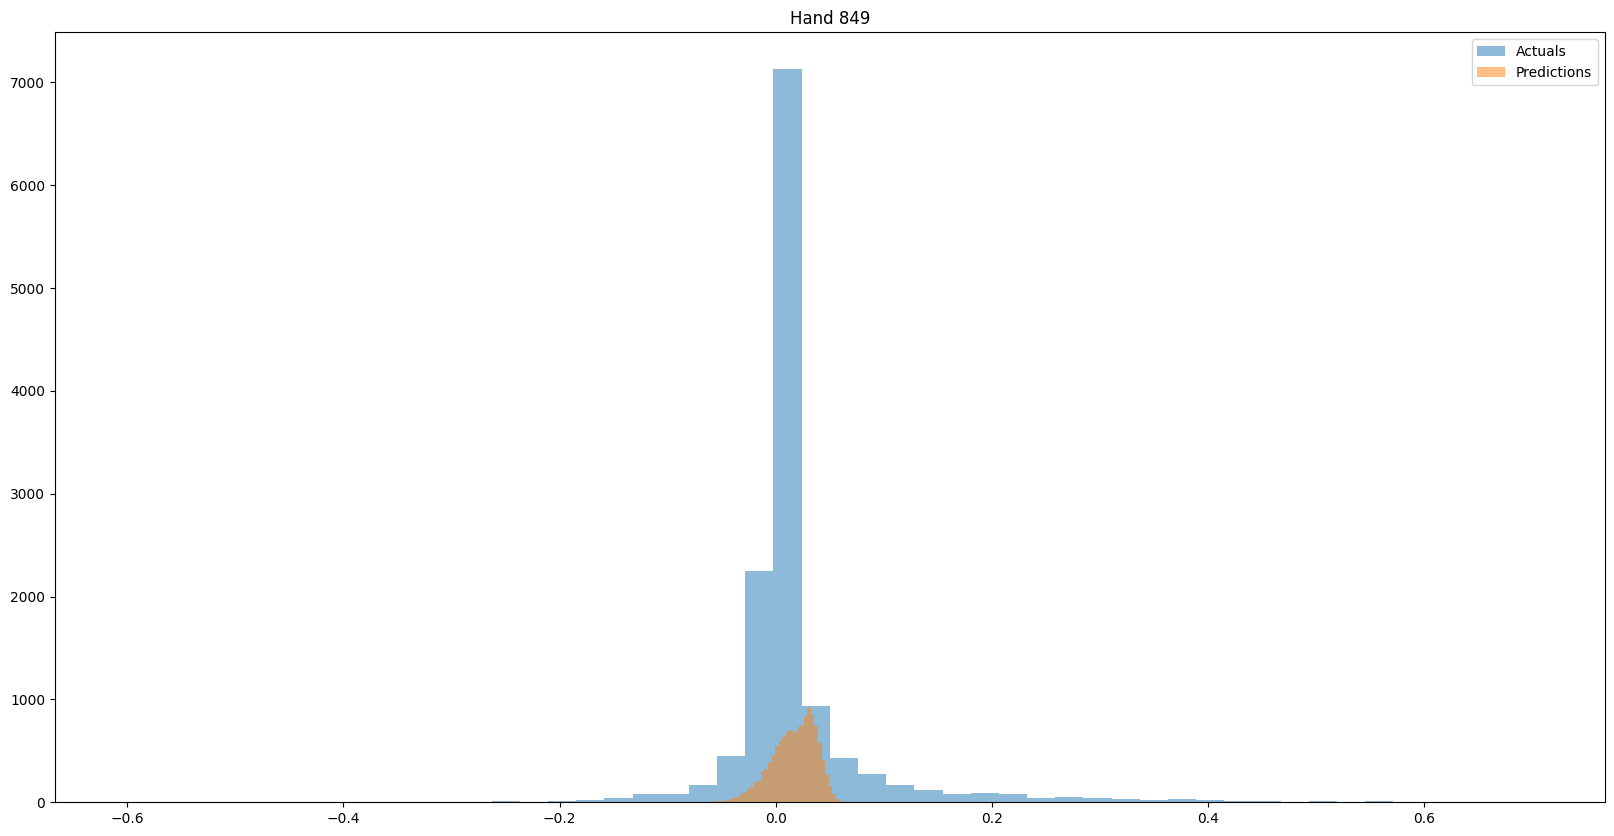

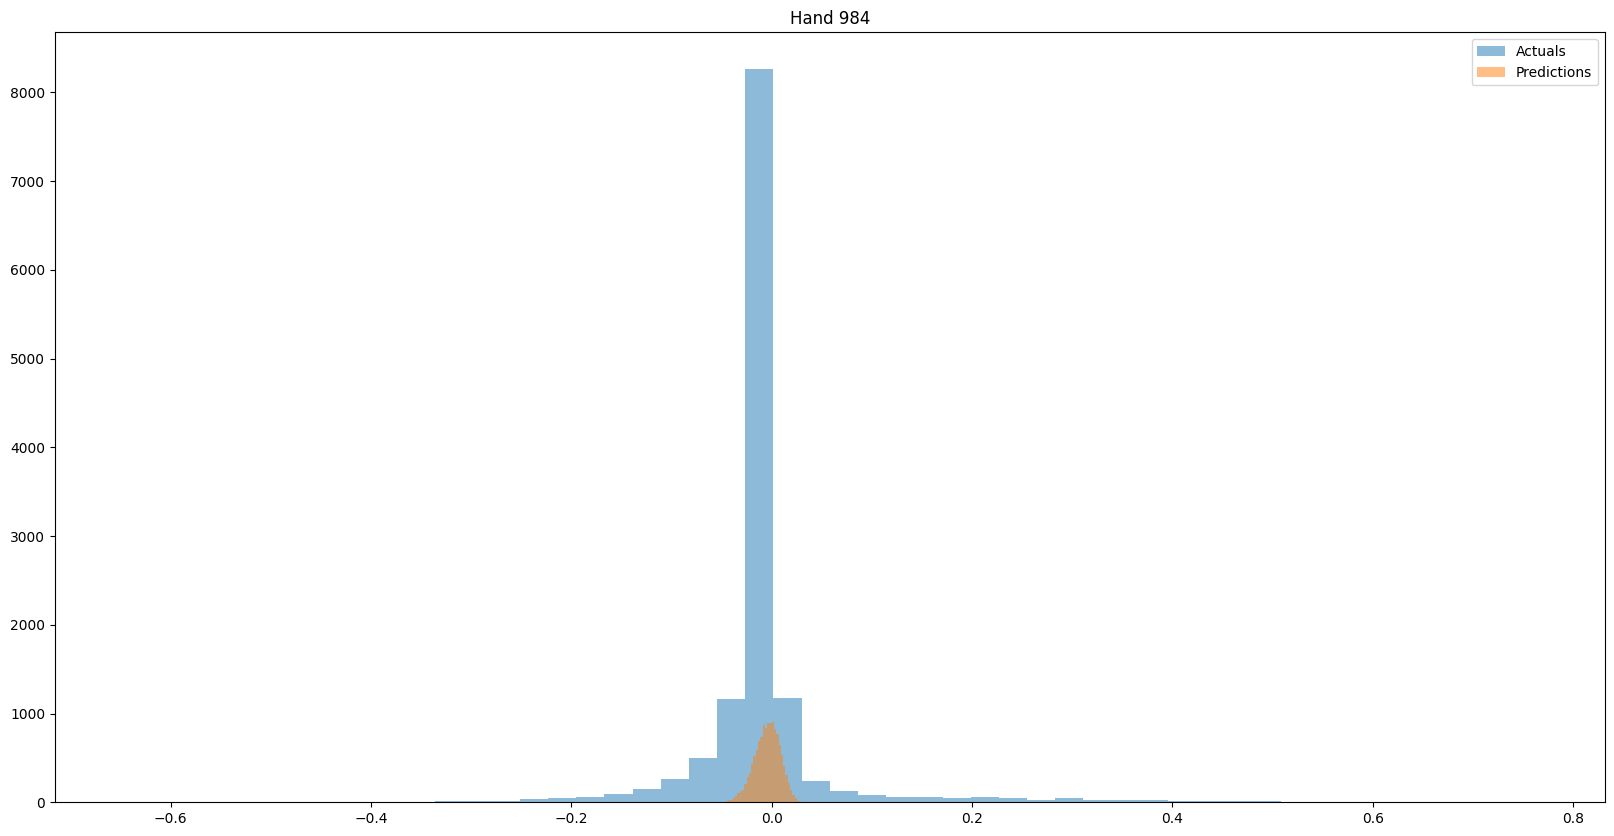

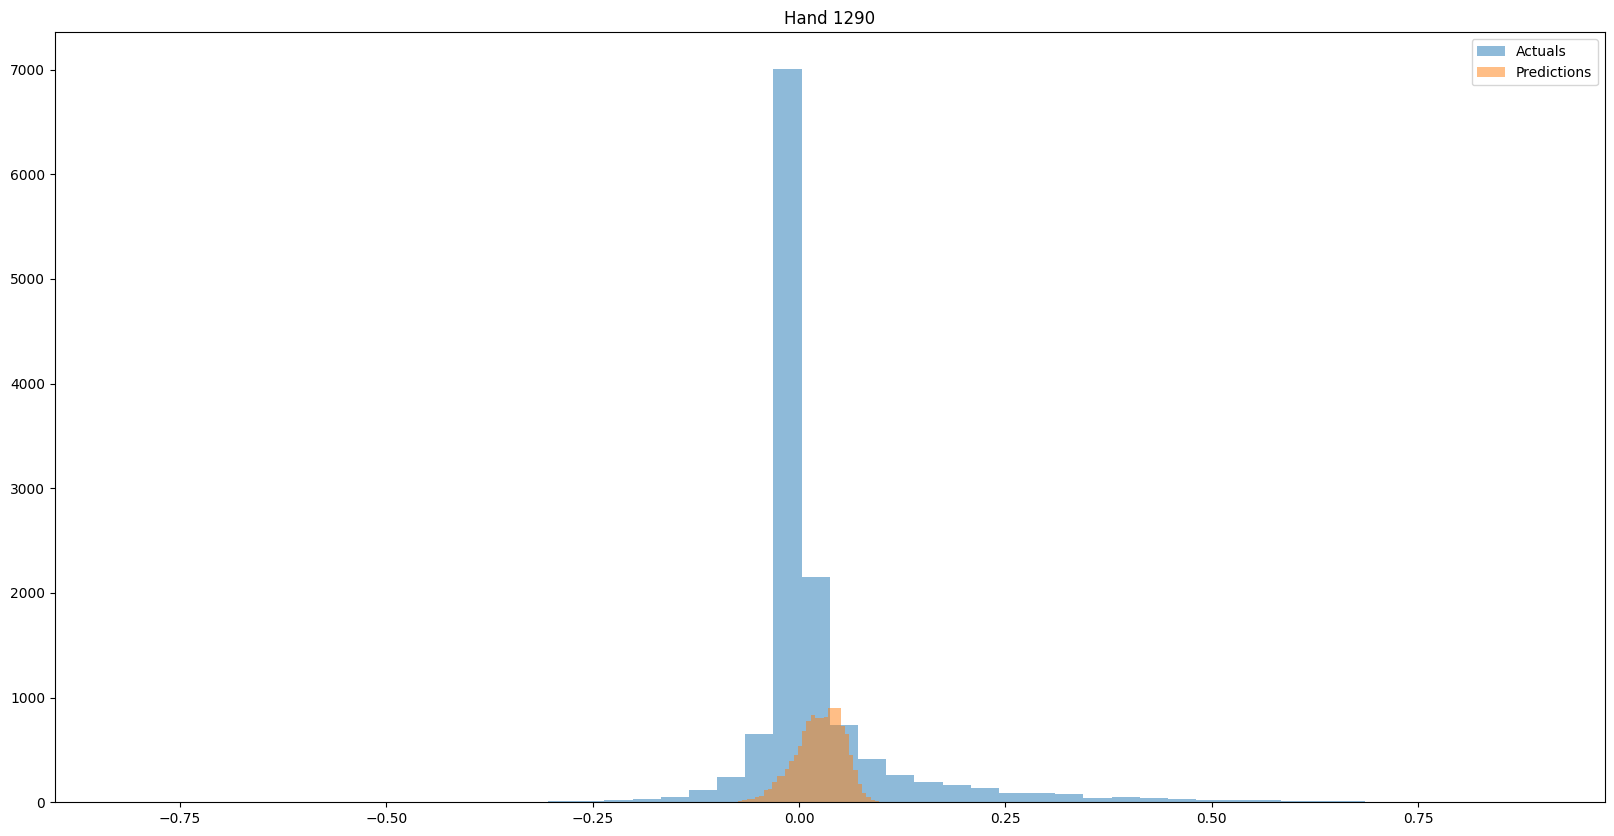

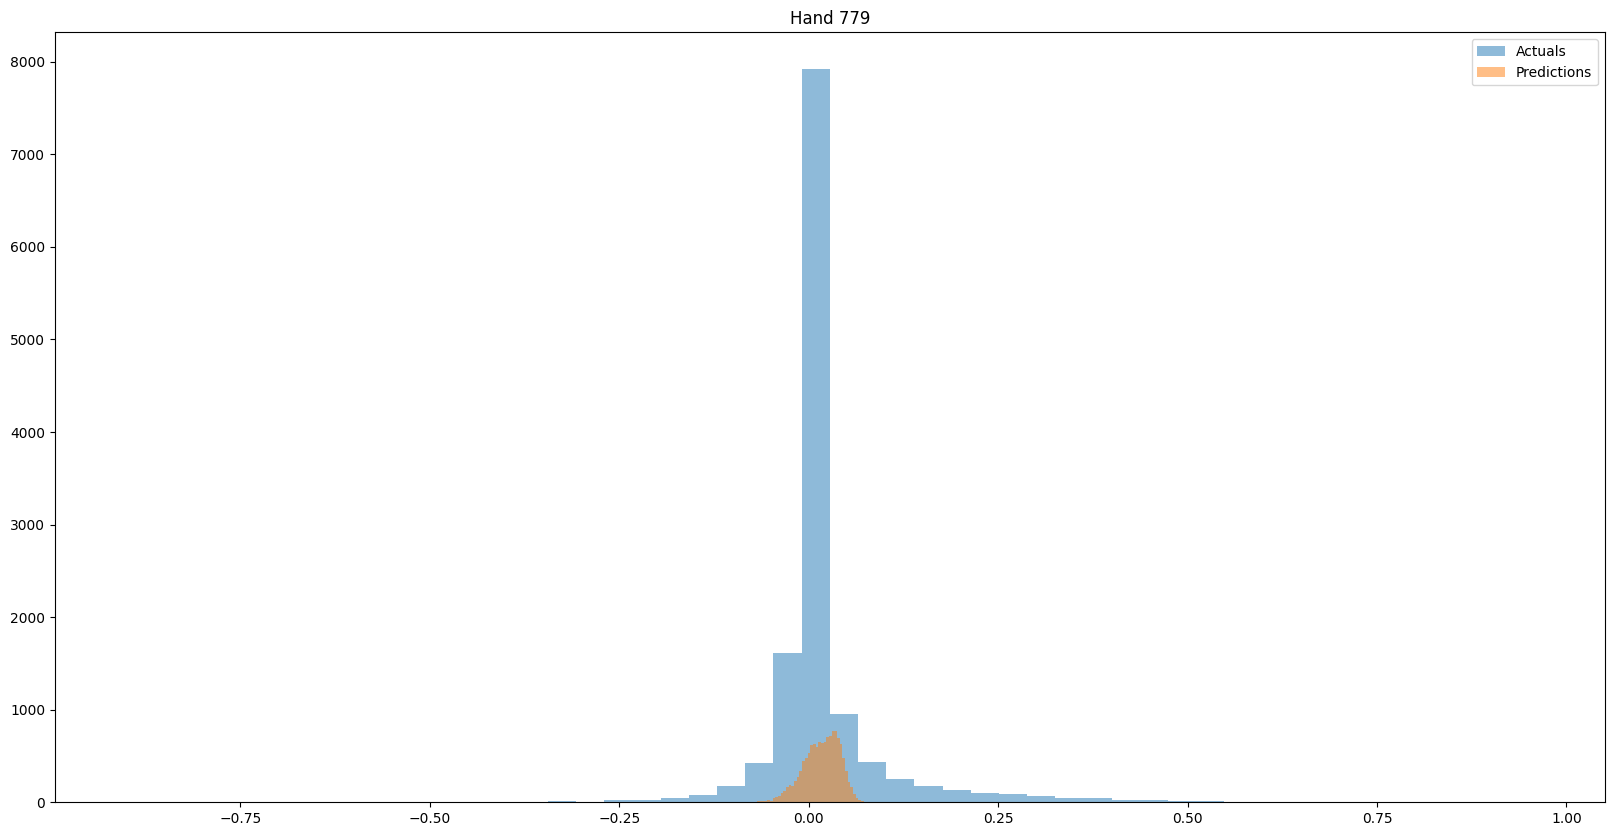

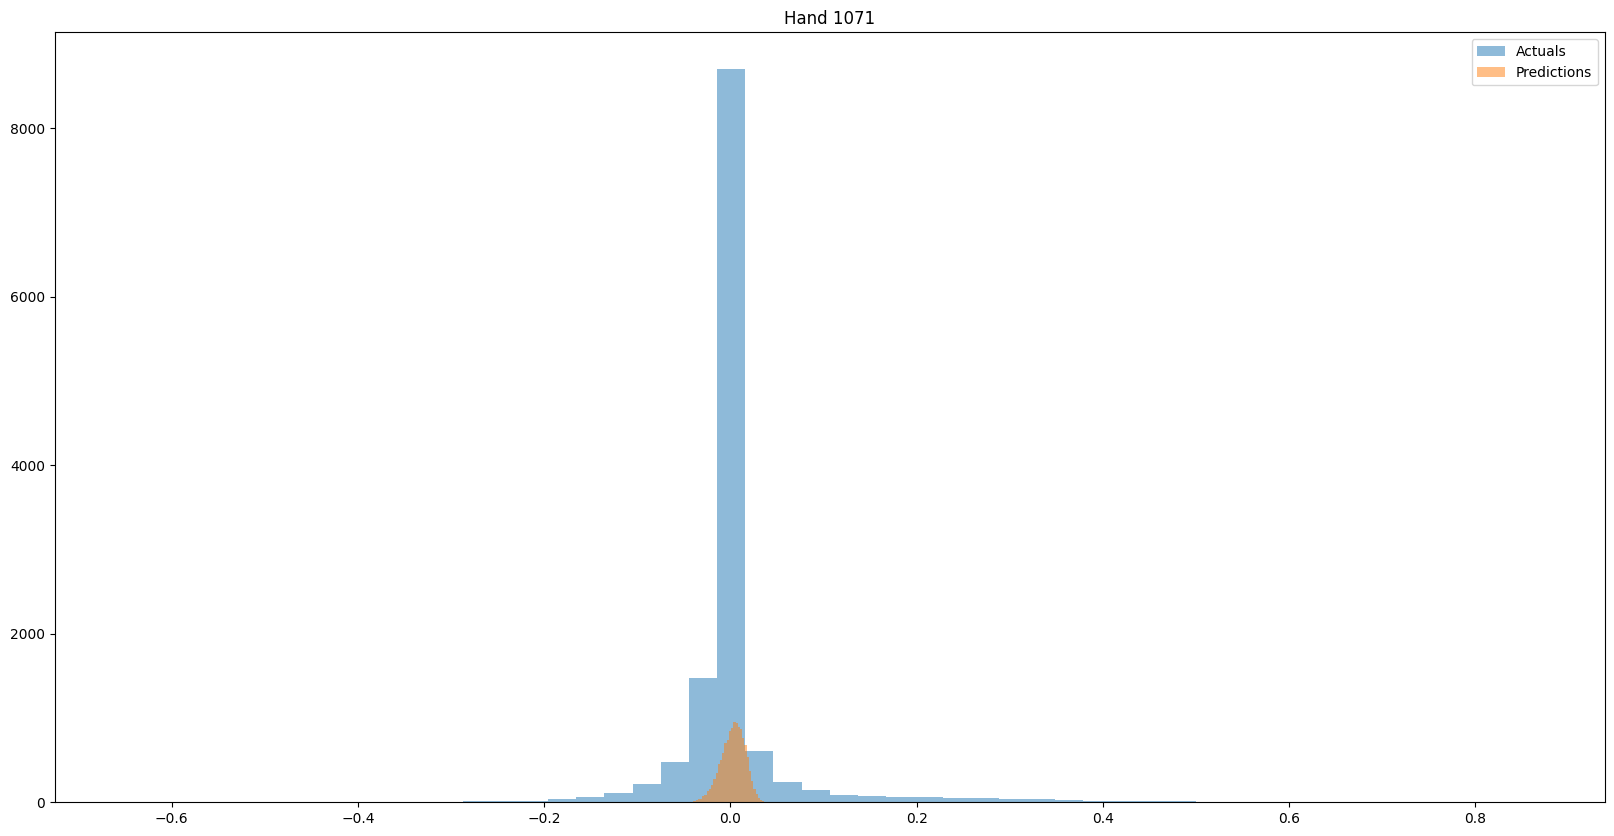

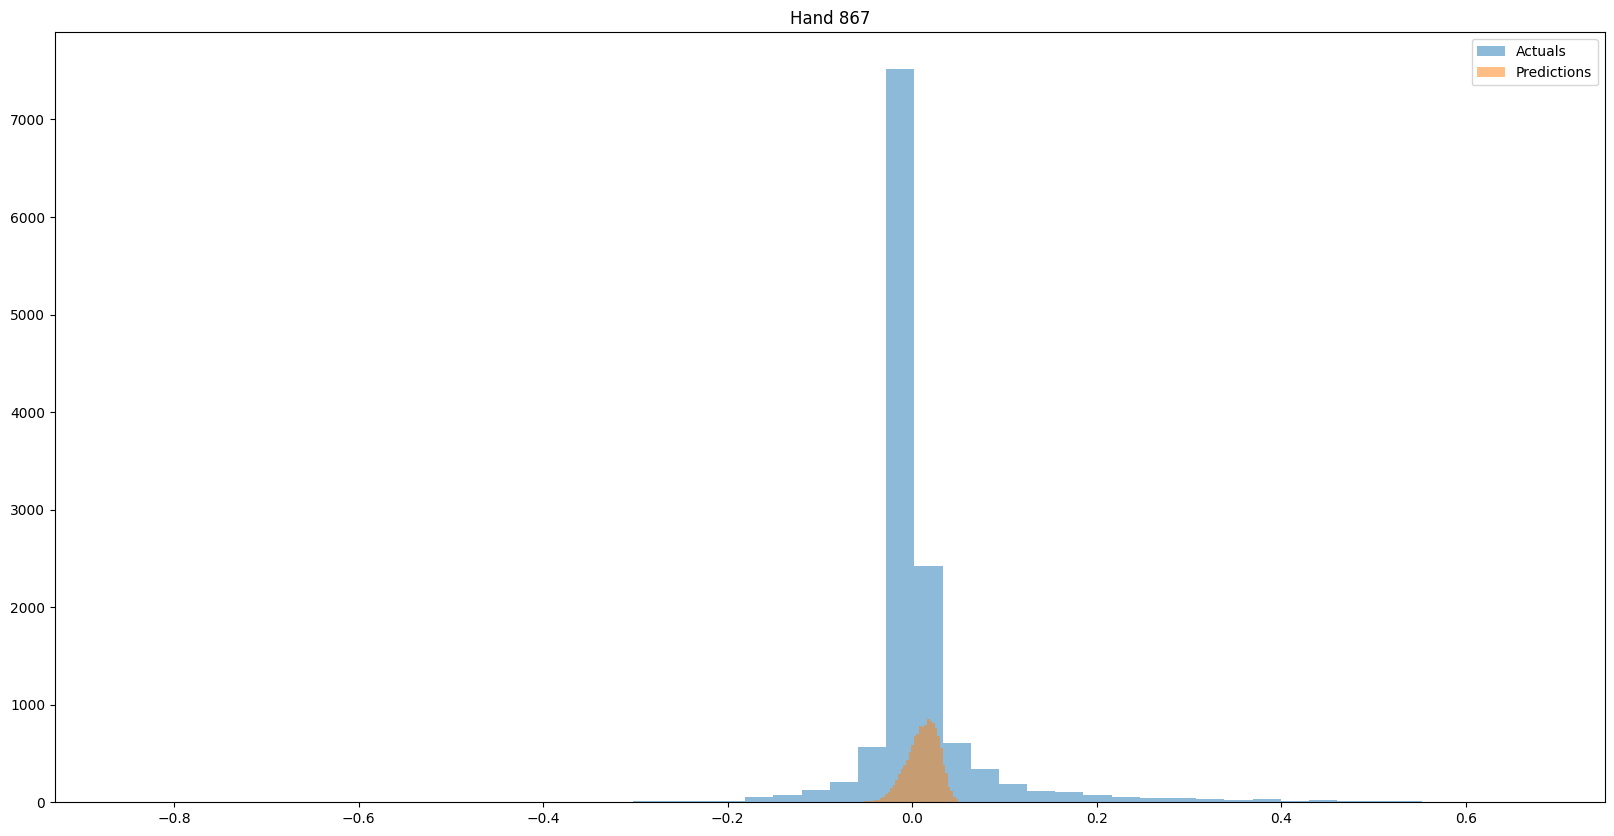

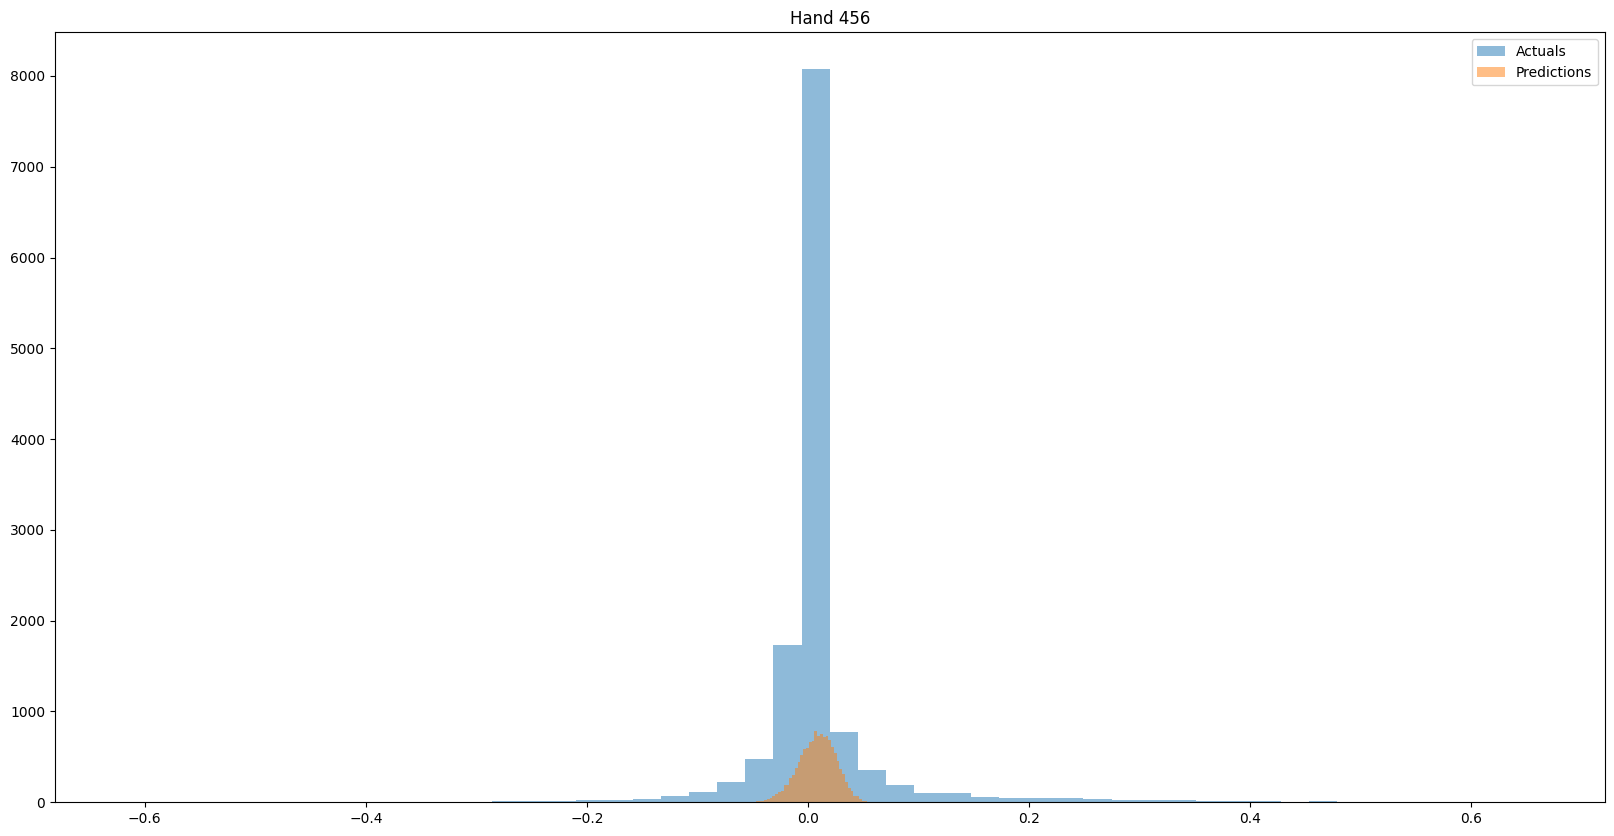

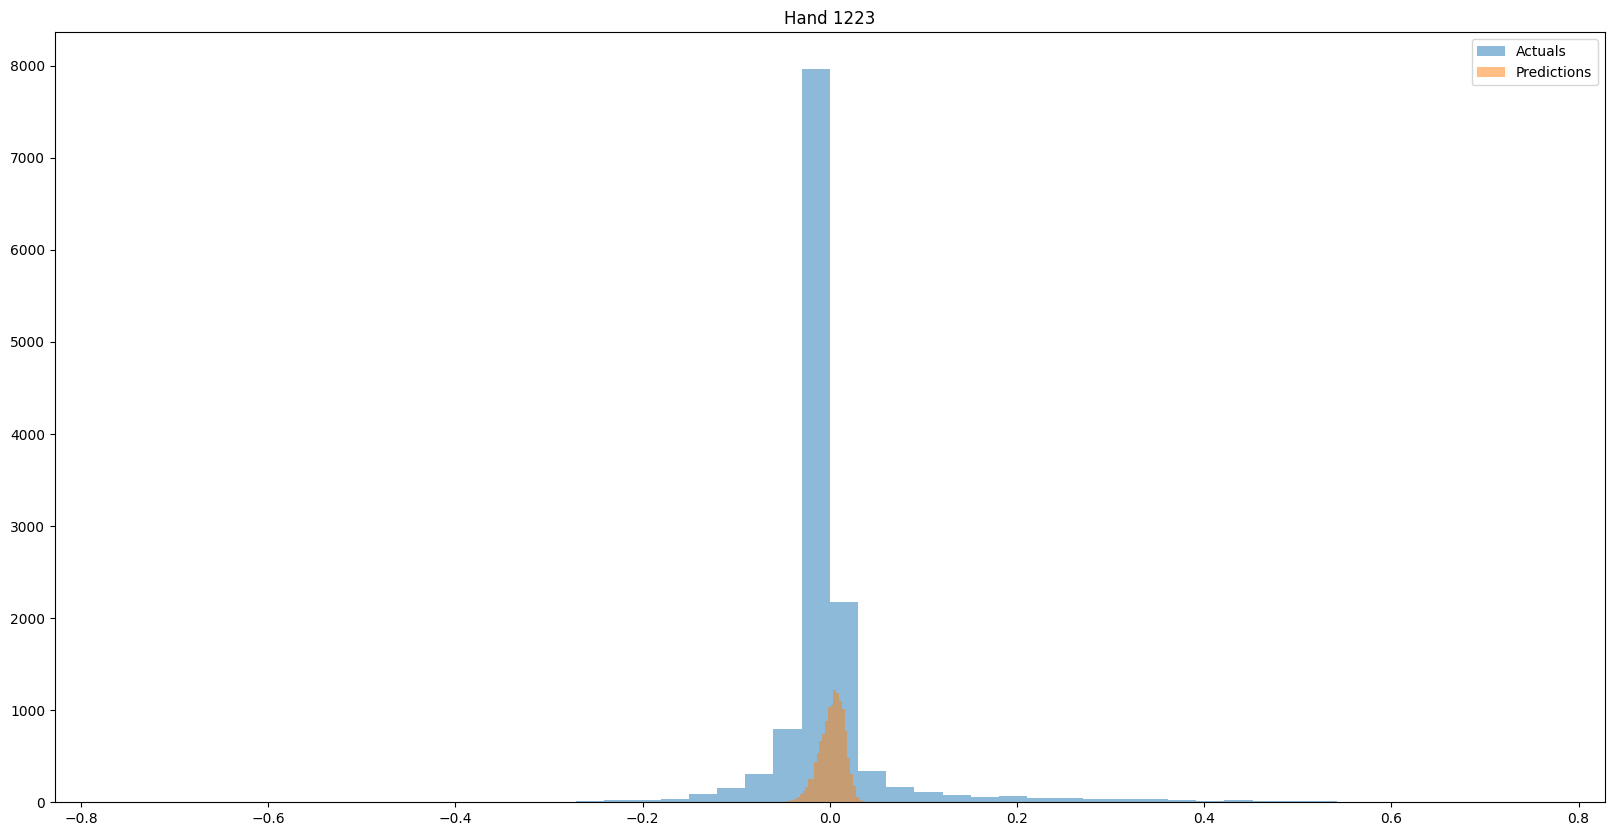

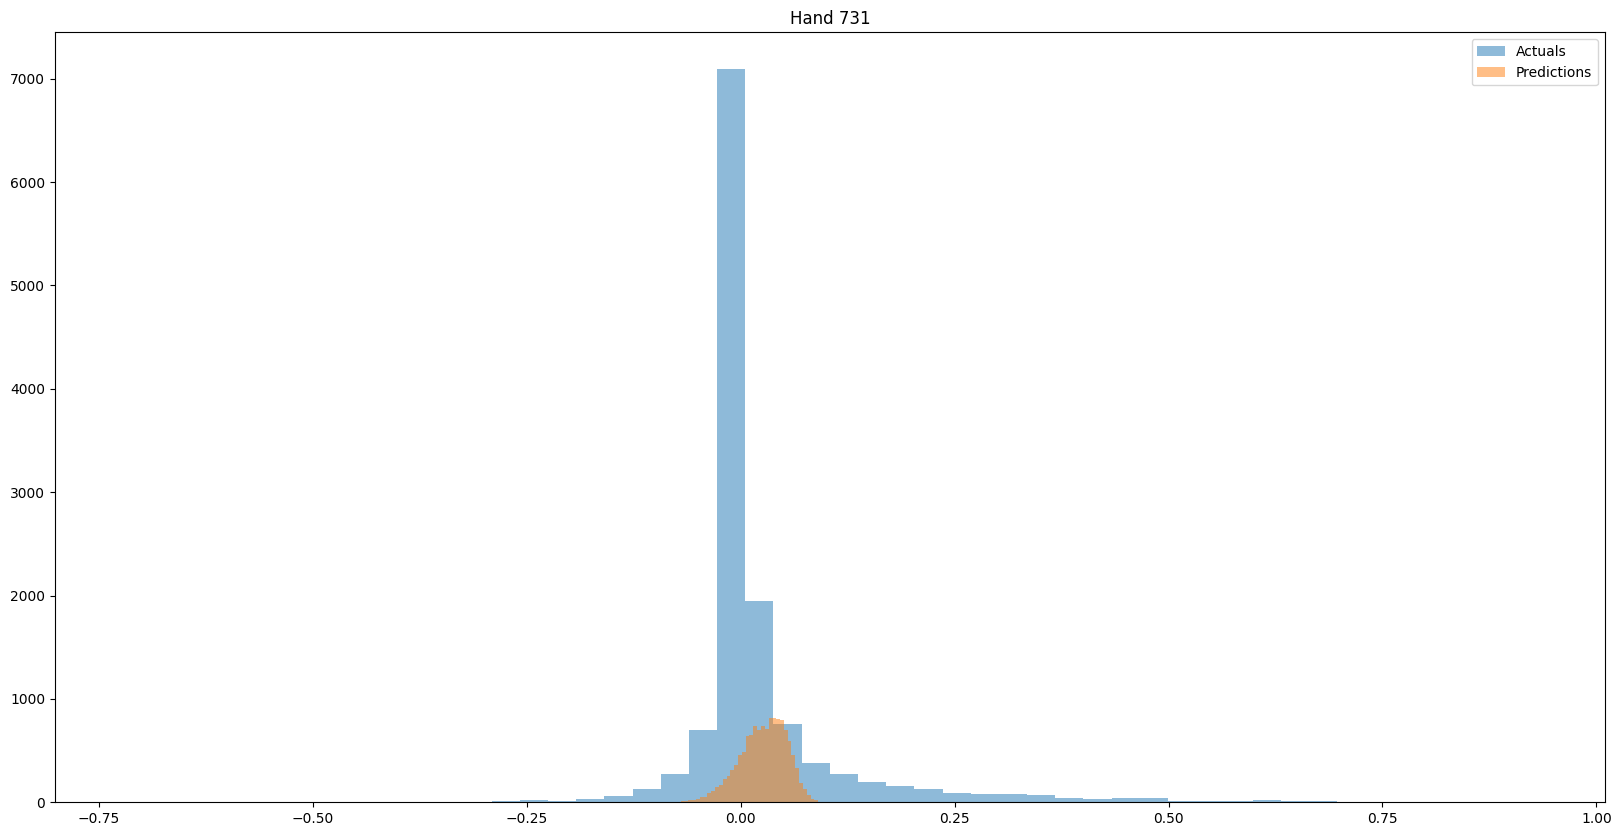

In [36]:
# Look at 10 random hands and compare the predicted and actual values
sample_is = np.random.choice(Y_val.shape[1], 10)
for i in sample_is:
    # Plot histogram of actual values
    fig, ax = plt.subplots(figsize=(20, 10))
    plt.hist(Y_val[:, i], bins=50, alpha=0.5, label="Actuals")
    plt.hist(Y_val_pred[:, i], bins=50, alpha=0.5, label="Predictions")
    plt.legend()
    plt.title(f"Hand {i}")
    plt.show()

In [28]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
final_epoch_number = int(average_optimal_epoch)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 6


In [29]:
# Clear memory
fold_results = []
gc.collect()

12228

### Testing

In [30]:
# Test the model
model = generate_model()
epochs = final_epoch_number
model.fit(X_train, Y_train, epochs=epochs)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/32


2024-05-03 11:16:05.006179: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


590/590 [==============================] - 35s 59ms/step - loss: 0.0128
Epoch 2/32
590/590 [==============================] - 34s 57ms/step - loss: 0.0119
Epoch 3/32
590/590 [==============================] - 34s 57ms/step - loss: 0.0110
Epoch 4/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0102
Epoch 5/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0095
Epoch 6/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0091
Epoch 7/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0090
Epoch 8/32
590/590 [==============================] - 34s 58ms/step - loss: 0.0089
Epoch 9/32
590/590 [==============================] - 36s 60ms/step - loss: 0.0088
Epoch 10/32
590/590 [==============================] - 35s 60ms/step - loss: 0.0088
Epoch 11/32
590/590 [==============================] - 36s 61ms/step - loss: 0.0087
Epoch 12/32
590/590 [==============================] - 36s 61ms/step - loss: 0.0087
Epoch 13/32


2024-05-03 11:34:50.190176: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


148/148 [==============================] - 3s 17ms/step - loss: 0.0089
Test MSE: 0.0089
Test RMSE: 0.0941


In [33]:
# As a baseline, calculate the RMSE of predicting only zeros
baseline_mse = np.mean(Y_test**2)
print(f"Baseline MSE: {baseline_mse:.4f}")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MSE: 0.0129
Baseline RMSE: 0.1136


In [34]:
# As a better baseline, calculate the RMSE of predicting the mean of the target variable
mean_target = np.mean(Y_train, axis=0)
mean_baseline_mse = np.mean((Y_test - mean_target)**2)
print(f"Mean Baseline MSE: {mean_baseline_mse:.4f}")
mean_baseline_rmse = np.sqrt(mean_baseline_mse)
print(f"Mean Baseline RMSE: {mean_baseline_rmse:.4f}")

Mean Baseline MSE: 0.0119
Mean Baseline RMSE: 0.1092


In [ ]:
# Clear memory
model = None
gc.collect()

3141

### Training of final model

In [ ]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=epochs)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

Epoch 1/396
 1/10 [==>...........................] - ETA: 2s - loss: 0.0447

2024-05-01 21:27:46.969824: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


10/10 [==============================] - 1s 41ms/step - loss: 0.0462
Epoch 2/396
10/10 [==============================] - 0s 30ms/step - loss: 0.0422
Epoch 3/396
10/10 [==============================] - 0s 30ms/step - loss: 0.0391
Epoch 4/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0366
Epoch 5/396
10/10 [==============================] - 0s 36ms/step - loss: 0.0346
Epoch 6/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0326
Epoch 7/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0312
Epoch 8/396
10/10 [==============================] - 0s 32ms/step - loss: 0.0299
Epoch 9/396
10/10 [==============================] - 0s 30ms/step - loss: 0.0289
Epoch 10/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0278
Epoch 11/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0270
Epoch 12/396
10/10 [==============================] - 0s 29ms/step - loss: 0.0262
Epoch 13/396
10/10 [=================

/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Load model
model = tf.keras.models.load_model(f"models/{latest_fname}")
gc.collect()

786

In [ ]:
# Test making a point prediction
X_test_point = X_test[0].reshape(1, -1)
Y_test_point = Y_test[0].reshape(1, -1)
print("X_test_point shape:", X_test_point.shape)
Y_pred_point = model.predict(X_test_point)
print("Test point prediction:")
print("Actual:", Y_test_point)
print("Predicted:", Y_pred_point)

X_test_point shape: (1, 2712)
1/1 [==============================] - 0s 31ms/step
Test point prediction:
Actual: [[ 0.04335213  0.04521447  0.07330771 ...  0.00545103 -0.01149098
  -0.0120648 ]]
Predicted: [[ 0.0455304   0.04117741  0.07303078 ...  0.0120005  -0.00112417
  -0.00029863]]


2024-05-01 21:30:03.769883: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
